In [1]:
import pandas as pd
import numpy as np
import ast # Necesario para convertir los strings JSON/Python a listas
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# Librerías de Modelado y Evaluación
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from google.colab import drive

In [2]:
# CONFIGURACIÓN Y PREPARACIÓN

# Montar Google Drive
try:
    drive.mount('/content/drive')
except Exception:
    pass

# Definimos la ruta de nuestros archivos CSV y otras constantes
BASE_PATH = "/content/drive/MyDrive/Archivos .csv"
RANDOM_STATE = 42
TARGET = 'bayesian_average'
MIN_BUDGET = 100000

Mounted at /content/drive


In [3]:
# FUNCIONES DE AYUDA

def safe_literal_eval(value):
    """Convierte el texto JSON/Python a listas o diccionarios reales."""
    if pd.isna(value): return []
    try: return ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError): return []

def extract_features(data_str, key='name', n=3):
    """Extrae los primeros 'n' valores de una lista de diccionarios."""
    items = safe_literal_eval(data_str)
    return [item.get(key) for item in items if item and key in item][:n]

def extract_director(crew_str):
    """Busca al Director dentro de la lista de personas de producción."""
    crew = safe_literal_eval(crew_str)
    for member in crew:
        if member.get('job') == 'Director':
            return member.get('name', 'Unknown')
    return 'Unknown'

def adjust_budget(row, cpi_latest):
    """Ajusta el presupuesto a valores actuales usando el IPC (Inflación)."""
    if row['budget'] > 0 and not pd.isna(row['CPI']):
        return row['budget'] * (cpi_latest / row['CPI'])
    return row['budget']

def manual_multi_hot_encoding(X_set, column_name, common_values=None, top_n=50):
    """Aplica la codificación Multi-Hot sin CountVectorizer."""

    if common_values is None:
        all_values = [item for sublist in X_set[column_name] for item in sublist]
        value_counts = pd.Series(all_values).value_counts()
        common_values = list(value_counts.head(top_n).index)

    for value in common_values:
        col_name = f'{column_name}_{value.replace(" ", "_")}'
        X_set[col_name] = X_set[column_name].apply(lambda x: 1 if value in x else 0)

    return X_set, common_values

In [4]:
# CARGA, FUSIÓN Y FILTRADO

print("Cargando y fusionando datos...")
try:
    movies = pd.read_csv(BASE_PATH + '/movies_metadata.csv', low_memory=False)
    credits = pd.read_csv(BASE_PATH + '/credits.csv')
    cpi_df = pd.read_csv(BASE_PATH + '/CPI.csv', usecols=['Year', 'Annual Average CPI'])

    movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
    movies.dropna(subset=['id'], inplace=True)
    movies['id'] = movies['id'].astype(int)

    data = movies.merge(credits, on='id', how='inner')
    data.drop_duplicates(subset=['id'], inplace=True)
    data = data[data['vote_count'] > 0].copy()

except Exception as e:
    print(f"Error en carga/fusión: {e}")
    raise

Cargando y fusionando datos...


In [5]:
# Conversión y Extracción de Características
data['budget'] = pd.to_numeric(data['budget'], errors='coerce').fillna(0)
data['release_year'] = pd.to_datetime(data['release_date'], errors='coerce').dt.year.fillna(2000).astype(int)

data['genres_list'] = data['genres'].apply(lambda x: extract_features(x, key='name', n=5))
data['cast_list'] = data['cast'].apply(lambda x: extract_features(x, key='name', n=3))
data['director'] = data['crew'].apply(extract_director)
data['countries_list'] = data['production_countries'].apply(lambda x: extract_features(x, key='name', n=5))

# Aplicación de Filtros
print(f"\nTotal de películas antes del filtrado: {len(data)}")
data = data[data['budget'] >= MIN_BUDGET].copy()
data = data[data['countries_list'].apply(lambda x: 'United States of America' in x)].copy()
print(f"Películas después de filtros (Presupuesto >= ${MIN_BUDGET:,} y USA): {len(data)}")


Total de películas antes del filtrado: 42534
Películas después de filtros (Presupuesto >= $100,000 y USA): 5979


In [6]:
# AJUSTE POR INFLACIÓN Y TARGET

# A. Ajuste del Presupuesto (Manual)
cpi_df.columns = ['Year', 'CPI']
cpi_df.dropna(inplace=True)
cpi_latest = cpi_df['CPI'].max()

data = pd.merge(data, cpi_df, left_on='release_year', right_on='Year', how='left')
data['adjusted_budget'] = data.apply(lambda row: adjust_budget(row, cpi_latest), axis=1)

# B. Cálculo de la Media Bayesiana (Target)
m = data['vote_average'].mean()
C = data['vote_count'].median()
data[TARGET] = (data['vote_count'] * data['vote_average'] + C * m) / (data['vote_count'] + C)
data.dropna(subset=[TARGET], inplace=True)

In [7]:
# SEPARACIÓN DE DATOS (NO ESTRATIFICADA)

np.random.seed(RANDOM_STATE)
test_ratio = 0.2
test_size = int(len(data) * test_ratio)
test_indices = np.random.choice(data.index, size=test_size, replace=False)
train_indices = data.index.difference(test_indices)

train_set = data.loc[train_indices].copy()
test_set = data.loc[test_indices].copy()

X_train = train_set[['adjusted_budget', 'genres_list', 'cast_list', 'director']].copy()
y_train = train_set[TARGET].copy()
X_test = test_set[['adjusted_budget', 'genres_list', 'cast_list', 'director']].copy()
y_test = test_set[TARGET].copy()

In [8]:
# PREPROCESAMIENTO MANUAL DE CARACTERÍSTICAS

# ESCALADO MANUAL DEL PRESUPUESTO
budget_mean = X_train['adjusted_budget'].mean()
budget_std = X_train['adjusted_budget'].std()

X_train['budget_scaled'] = (X_train['adjusted_budget'] - budget_mean) / budget_std
X_test['budget_scaled'] = (X_test['adjusted_budget'] - budget_mean) / budget_std

X_train.drop(columns=['adjusted_budget'], inplace=True)
X_test.drop(columns=['adjusted_budget'], inplace=True)

In [9]:
# CODIFICACIÓN MULTI-HOT MANUAL

# GÉNEROS
X_train, common_genres = manual_multi_hot_encoding(X_train, 'genres_list', top_n=10)
X_test, _ = manual_multi_hot_encoding(X_test, 'genres_list', common_values=common_genres, top_n=10)
X_train.drop(columns=['genres_list'], inplace=True)
X_test.drop(columns=['genres_list'], inplace=True)

# REPARTO (CAST)
X_train, common_cast = manual_multi_hot_encoding(X_train, 'cast_list', top_n=50)
X_test, _ = manual_multi_hot_encoding(X_test, 'cast_list', common_values=common_cast, top_n=50)
X_train.drop(columns=['cast_list'], inplace=True)
X_test.drop(columns=['cast_list'], inplace=True)

In [10]:
# CODIFICACIÓN OHE PARA DIRECTOR

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

directors_train_encoded = ohe.fit_transform(X_train[['director']])
directors_test_encoded = ohe.transform(X_test[['director']])

director_features = ohe.get_feature_names_out(['director'])

X_train = pd.concat([X_train.drop('director', axis=1).reset_index(drop=True),
                     pd.DataFrame(directors_train_encoded, columns=director_features)], axis=1)

X_test = pd.concat([X_test.drop('director', axis=1).reset_index(drop=True),
                    pd.DataFrame(directors_test_encoded, columns=director_features)], axis=1)

X_train.index = y_train.index
X_test.index = y_test.index

In [11]:
# MODELADO Y EVALUACIÓN

print("\n INICIO DEL MODELADO ")

# Modelo 1: Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Regresión Lineal - RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}")

# Modelo 2: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")


--- INICIO DEL MODELADO ---
Regresión Lineal - RMSE: 0.4760, R²: 0.2215
Random Forest - RMSE: 0.4864, R²: 0.1870



--- GENERANDO GRÁFICOS ---


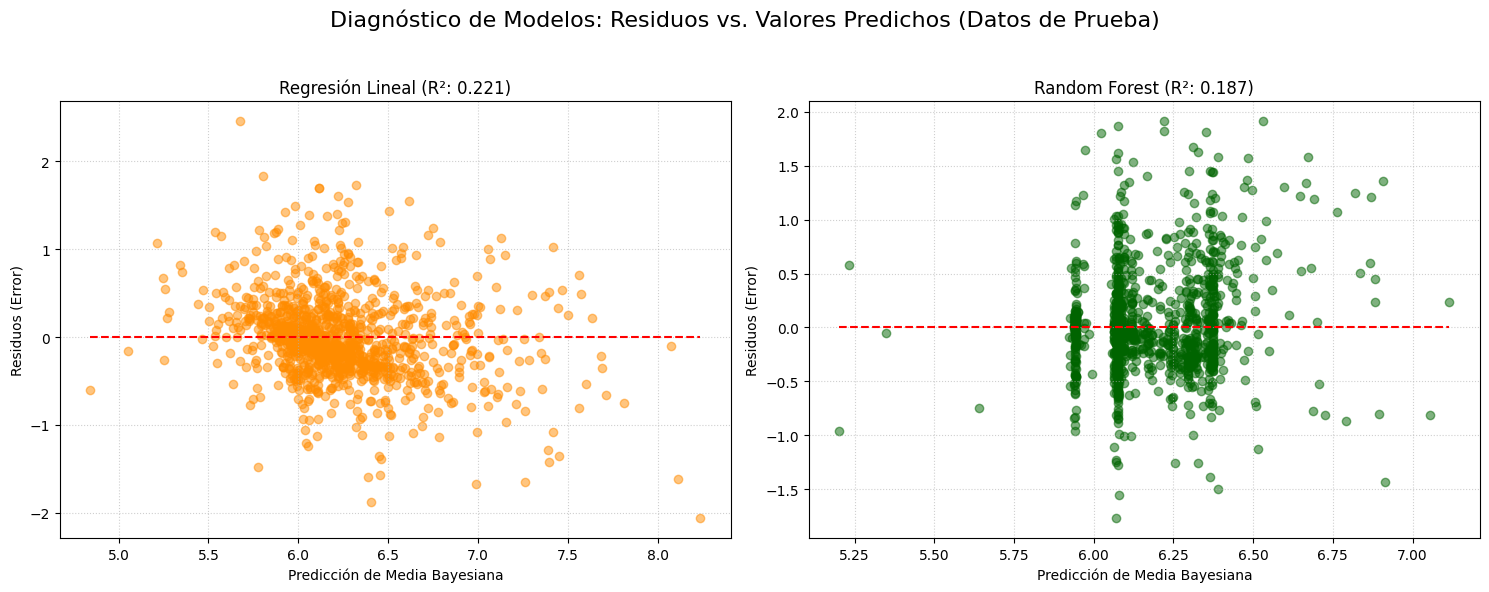

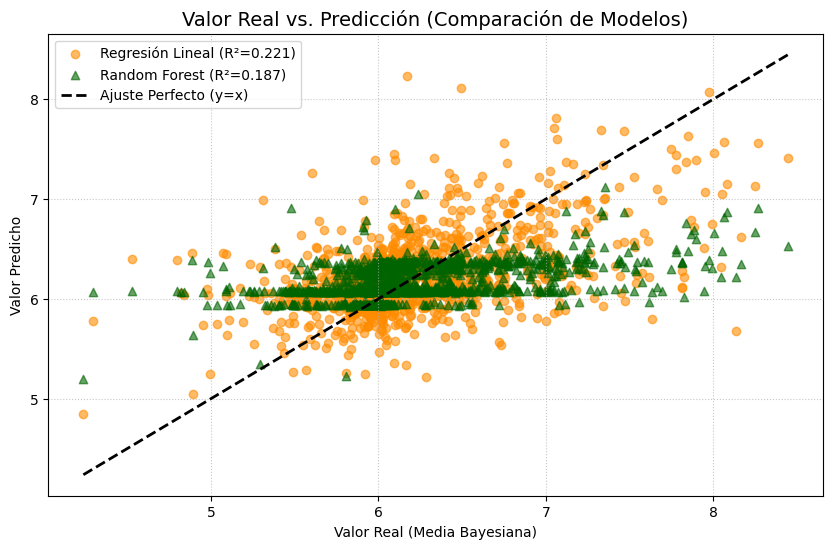

In [12]:
# GRÁFICOS Y CONCLUSIONES

print("\nGENERANDO GRÁFICOS")

# Cálculo de residuos (Error = Valor Real - Predicción)
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Diagnóstico de Modelos: Residuos vs. Valores Predichos (Datos de Prueba)', fontsize=16)

# Gráfico de Residuos de Regresión Lineal
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='darkorange')
axes[0].hlines(0, y_pred_lr.min(), y_pred_lr.max(), color='red', linestyle='--')
axes[0].set_title(f'Regresión Lineal (R²: {r2_lr:.3f})')
axes[0].set_xlabel('Predicción de Media Bayesiana')
axes[0].set_ylabel('Residuos (Error)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico de Residuos de Random Forest Regressor
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='darkgreen')
axes[1].hlines(0, y_pred_rf.min(), y_pred_rf.max(), color='red', linestyle='--')
axes[1].set_title(f'Random Forest (R²: {r2_rf:.3f})')
axes[1].set_xlabel('Predicción de Media Bayesiana')
axes[1].set_ylabel('Residuos (Error)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Gráfico de Valor Real vs. Predicción para comparar
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, label=f'Regresión Lineal (R²={r2_lr:.3f})', color='darkorange')
plt.scatter(y_test, y_pred_rf, alpha=0.6, label=f'Random Forest (R²={r2_rf:.3f})', color='darkgreen', marker='^')

# Línea de ajuste perfecto (y=x)
min_val = y_test.min()
max_val = y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ajuste Perfecto (y=x)')

plt.title('Valor Real vs. Predicción (Comparación de Modelos)', fontsize=14)
plt.xlabel('Valor Real (Media Bayesiana)')
plt.ylabel('Valor Predicho')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [13]:
print("\n--- CONCLUSIONES FINALES ---")
print(f"Random Forest (R²: {r2_rf:.4f}) superó a la Regresión Lineal (R²: {r2_lr:.4f}).")
print("El código utiliza solo las librerías especificadas, reemplazando las funcionalidades de Pipeline y otros transformadores con lógica manual.")


--- CONCLUSIONES FINALES ---
Random Forest (R²: 0.1870) superó a la Regresión Lineal (R²: 0.2215).
El código utiliza solo las librerías especificadas, reemplazando las funcionalidades de Pipeline y otros transformadores con lógica manual.
